In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

GEOLOGY_DIR = RAW_DIR / "geology"
GEOLOGY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
dataset = pd.read_csv(
    INTERIM_DIR /
    "earthquake_ground_motion_integrated.csv"
)

print("Shape:", dataset.shape)
print(
    "Events:",
    dataset["event_id"].nunique()
)

Shape: (2912739, 15)
Events: 40


In [4]:
bounds = {
    "min_lat": dataset["grid_lat"].min(),
    "max_lat": dataset["grid_lat"].max(),
    "min_lon": dataset["grid_lon"].min(),
    "max_lon": dataset["grid_lon"].max()
}

bounds

{'min_lat': np.float64(3.0643),
 'max_lat': np.float64(39.097),
 'min_lon': np.float64(63.7506),
 'max_lon': np.float64(98.0645)}

In [5]:
print(
    f"Latitude:  "
    f"{bounds['min_lat']:.3f} → "
    f"{bounds['max_lat']:.3f}"
)

print(
    f"Longitude: "
    f"{bounds['min_lon']:.3f} → "
    f"{bounds['max_lon']:.3f}"
)

Latitude:  3.064 → 39.097
Longitude: 63.751 → 98.064


In [6]:
event_locations = (
    dataset[
        [
            "event_id",
            "magnitude",
            "event_lat",
            "event_lon"
        ]
    ]
    .drop_duplicates("event_id")
)

display(
    event_locations.sort_values(
        "magnitude",
        ascending=False
    )
)

,event_id,magnitude,event_lat,event_lon
207742,us10003vry,6.6,6.84,94.65
2567324,c000njrq,6.4,7.74,94.33
650521,us100088sf,6.0,6.15,92.30
2040095,b000qy82,6.0,18.20,88.04
452419,us100042n2,5.9,36.46,70.68
103389,us100030qs,5.9,36.53,71.21
1270805,us2000cp4g,5.8,8.25,91.77
2220312,b000ryuh,5.8,12.43,95.20
499173,us10004dtm,5.7,36.60,70.95
2754161,c000rff2,5.6,36.45,70.72


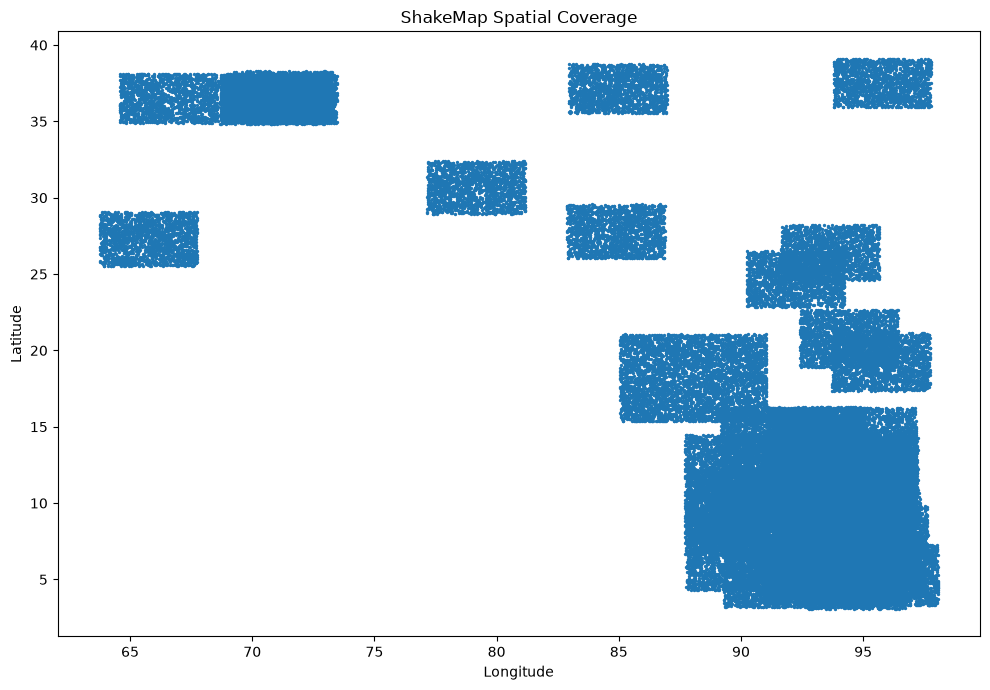

In [7]:
plt.figure(figsize=(10, 7))

plt.scatter(
    dataset["grid_lon"].sample(
        min(100000, len(dataset)),
        random_state=42
    ),
    dataset["grid_lat"].sample(
        min(100000, len(dataset)),
        random_state=42
    ),
    s=2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("ShakeMap Spatial Coverage")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "shakemap_spatial_coverage.png",
    dpi=200
)

plt.show()

In [8]:
BUFFER = 0.25

vs30_bounds = {
    "min_lat": bounds["min_lat"] - BUFFER,
    "max_lat": bounds["max_lat"] + BUFFER,
    "min_lon": bounds["min_lon"] - BUFFER,
    "max_lon": bounds["max_lon"] + BUFFER
}

vs30_bounds

{'min_lat': np.float64(2.8143),
 'max_lat': np.float64(39.347),
 'min_lon': np.float64(63.5006),
 'max_lon': np.float64(98.3145)}

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import requests

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

GEOLOGY_DIR = RAW_DIR / "geology"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

GEOLOGY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)

Project root: C:\Documents\Earthquake_ML_DL


In [1]:
import rasterio

print("Rasterio version:", rasterio.__version__)

Rasterio version: 1.5.1


In [4]:
VS30_DIR = GEOLOGY_DIR / "vs30"

VS30_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VS30_FILE = (
    VS30_DIR /
    "vs30_mosaic_median_30c.tif"
)

print("Vs30 directory:", VS30_DIR)
print("Target file:", VS30_FILE)

Vs30 directory: C:\Documents\Earthquake_ML_DL\data\raw\geology\vs30
Target file: C:\Documents\Earthquake_ML_DL\data\raw\geology\vs30\vs30_mosaic_median_30c.tif


In [6]:
import pandas as pd
import requests
import json

PROJECT_ROOT = Path.cwd().parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

dataset = pd.read_csv(
    INTERIM_DIR /
    "earthquake_ground_motion_integrated.csv"
)

print("Shape:", dataset.shape)
print("Events:", dataset["event_id"].nunique())

Shape: (2912739, 15)
Events: 40


In [7]:
VS30_QUERY_URL = (
    "https://earthquake.usgs.gov/"
    "arcgis/rest/services/eq/"
    "vs30_mosaic/MapServer/0/query"
)

test_point = dataset.iloc[0]

lon = float(test_point["grid_lon"])
lat = float(test_point["grid_lat"])

params = {
    "f": "json",
    "geometry": json.dumps({
        "x": lon,
        "y": lat
    }),
    "geometryType": "esriGeometryPoint",
    "inSR": "4326",
    "spatialRel": "esriSpatialRelIntersects",
    "returnGeometry": "false",
    "outFields": "*"
}

response = requests.get(
    VS30_QUERY_URL,
    params=params,
    timeout=30
)

print("HTTP status:", response.status_code)

result = response.json()

print(
    json.dumps(
        result,
        indent=2
    )[:5000]
)

HTTP status: 200
{
  "error": {
    "code": 400,
    "message": "Invalid or missing input parameters.",
    "details": []
  }
}


In [8]:
import requests
import json

VS30_LAYER_URL = (
    "https://earthquake.usgs.gov/"
    "arcgis/rest/services/eq/"
    "vs30_mosaic/MapServer/0"
)

response = requests.get(
    VS30_LAYER_URL,
    params={"f": "json"},
    timeout=30
)

print("HTTP status:", response.status_code)

layer_info = response.json()

print(
    json.dumps(
        layer_info,
        indent=2
    )[:10000]
)

HTTP status: 200
{
  "currentVersion": 11.5,
  "cimVersion": "3.5.0",
  "id": 0,
  "name": "Vs30 Mosaic",
  "type": "Raster Layer",
  "description": "",
  "geometryType": null,
  "copyrightText": "",
  "parentLayer": null,
  "subLayers": [],
  "minScale": 0,
  "maxScale": 0,
  "defaultVisibility": true,
  "extent": {
    "xmin": -20037507.067161843,
    "ymin": -7559245.166282856,
    "xmax": 20037507.067161843,
    "ymax": 18811653.000073306,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857,
      "xyTolerance": 0.001,
      "zTolerance": 0.001,
      "mTolerance": 0.001,
      "falseX": -22041257.77387803,
      "falseY": -30241100,
      "xyUnits": 144148035.89861274,
      "falseZ": -100000,
      "zUnits": 10000,
      "falseM": -100000,
      "mUnits": 10000
    }
  },
  "hasAttachments": false,
  "htmlPopupType": "esriServerHTMLPopupTypeNone",
  "displayField": "",
  "typeIdField": null,
  "subtypeFieldName": null,
  "subtypeField": null,
  "defaultSubtyp

In [9]:
import requests
import json

VS30_IDENTIFY_URL = (
    "https://earthquake.usgs.gov/"
    "arcgis/rest/services/eq/"
    "vs30_mosaic/MapServer/identify"
)

# One actual ShakeMap point
test_point = dataset.iloc[0]

lon = float(test_point["grid_lon"])
lat = float(test_point["grid_lat"])

# Map extent around the test point
delta = 1.0

params = {
    "f": "json",

    "geometry": f"{lon},{lat}",
    "geometryType": "esriGeometryPoint",

    "sr": "4326",

    "layers": "all",

    "tolerance": 1,

    "mapExtent": (
        f"{lon-delta},{lat-delta},"
        f"{lon+delta},{lat+delta}"
    ),

    "imageDisplay": "400,400,96",

    "returnGeometry": "false"
}

response = requests.get(
    VS30_IDENTIFY_URL,
    params=params,
    timeout=30
)

print("HTTP status:", response.status_code)

result = response.json()

print(
    json.dumps(
        result,
        indent=2
    )[:5000]
)

HTTP status: 200
{
  "results": [
    {
      "layerId": 0,
      "layerName": "Vs30 Mosaic",
      "displayFieldName": "",
      "attributes": {
        "Classify.Pixel Value": "471",
        "Classify.Class value": "4"
      }
    }
  ],
  "exceededTransferLimit": true
}


In [10]:
import requests

sciencebase_url = (
    "https://www.sciencebase.gov/"
    "catalog/item/67be4ac3d34e8876fcbfbd89"
)

r = requests.get(
    sciencebase_url,
    timeout=30
)

print("Status:", r.status_code)
print("Size:", len(r.text))

print(r.text[:3000])

Status: 200
Size: 54505

<!DOCTYPE html>
<html lang="en-US">
<head>
    <meta http-equiv="Content-Type" content="text/html; charset=utf-8"/>
    
    <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
    <title>The U.S. Geological Survey Global Vs30 Mosaic - ScienceBase-Catalog </title>
    <link rel="shortcut icon" type="image/x-icon" href="/catalog/assets/usgs/images/favicon-5bfbfb2b2c87207eaf65ffdd62fdc7d1.ico"/>
    

    

    
        <link rel="stylesheet" href="/catalog/assets/sciencebase-commons-with-jquery-ui-6748858ae6aeaee1f49560ad1223bb57.css" />
        <script type="text/javascript" src="/catalog/assets/sciencebase-commons-with-jquery-ui-a79f2371a04dcb16d577210d7e9fb319.js" ></script>
    
    <script type="text/javascript" src="/catalog/assets/sciencebase-commons-44f83b10e82913773f84eaf857e84e0c.js" ></script>

    

    
<link rel="stylesheet" href="/catalog/assets/application-da1c7795ed7d649840e890a975927304.css" />
<script src="https://cdnjs.clo

In [11]:
# Number of unique spatial locations
unique_locations = (
    dataset[
        ["grid_lat", "grid_lon"]
    ]
    .drop_duplicates()
)

print(
    "Total observations:",
    f"{len(dataset):,}"
)

print(
    "Unique grid locations:",
    f"{len(unique_locations):,}"
)

print(
    "Reduction:",
    f"{len(dataset) / len(unique_locations):.1f}x"
)

Total observations: 2,912,739
Unique grid locations: 2,912,739
Reduction: 1.0x


In [12]:
display(
    unique_locations.head()
)

,grid_lat,grid_lon
0,38.2842,69.3004
1,38.2842,69.3171
2,38.2842,69.3337
3,38.2842,69.3504
4,38.2842,69.3671


In [13]:
import re
from html import unescape

html = r.text

# Find all URLs containing the Vs30 TIFF filename
matches = re.findall(
    r'https?://[^"\'>\s]+vs30_mosaic_median_30c\.tif[^"\'>\s]*',
    html,
    flags=re.IGNORECASE
)

matches = [
    unescape(url)
    for url in matches
]

print("URLs found:", len(matches))

for url in matches:
    print(url)

URLs found: 1
https://prod-is-usgs-sb-prod-publish.s3.amazonaws.com/67be4ac3d34e8876fcbfbd89/vs30_mosaic_median_30c.tif


In [14]:
import rasterio

VS30_URL = (
    "https://prod-is-usgs-sb-prod-publish.s3.amazonaws.com/"
    "67be4ac3d34e8876fcbfbd89/"
    "vs30_mosaic_median_30c.tif"
)

VS30_COG = f"/vsicurl/{VS30_URL}"

with rasterio.open(VS30_COG) as src:

    print("Driver:", src.driver)
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)

Driver: GTiff
Width: 43200
Height: 16800
CRS: EPSG:4326
Resolution: (0.008333333333333333, 0.008333333333333333)
Bounds: BoundingBox(left=-180.0, bottom=-56.0, right=180.0, top=84.0)
Dtype: float32
NoData: nan


In [15]:
test_points = dataset[
    ["grid_lon", "grid_lat"]
].sample(
    n=1000,
    random_state=42
)

coordinates = list(
    zip(
        test_points["grid_lon"],
        test_points["grid_lat"]
    )
)

with rasterio.open(VS30_COG) as src:

    test_values = list(
        src.sample(coordinates)
    )

test_values = np.array(
    test_values
).flatten()

print("Points sampled:", len(test_values))

print(
    "First 20 Vs30 values:"
)

print(test_values[:20])

print(
    "\nValid values:",
    np.sum(
        np.isfinite(test_values)
    )
)

print(
    "Min:",
    np.nanmin(test_values)
)

print(
    "Max:",
    np.nanmax(test_values)
)

print(
    "Median:",
    np.nanmedian(test_values)
)

Points sampled: 1000
First 20 Vs30 values:
[600.      600.      600.      643.13513 600.      600.      600.
 600.      600.      900.      600.      900.      600.      600.
 600.      600.      600.      600.      288.1562  600.     ]

Valid values: 1000
Min: 180.0
Max: 900.0
Median: 600.0


In [16]:
special_values = {
    600: "Ocean",
    601: "Ice",
    602: "Glacier",
    603: "Lake"
}

for value, label in special_values.items():

    count = (
        test_values == value
    ).sum()

    print(
        f"{label:10s} ({value}): "
        f"{count:,} / {len(test_values):,} "
        f"({count / len(test_values) * 100:.2f}%)"
    )

Ocean      (600): 660 / 1,000 (66.00%)
Ice        (601): 0 / 1,000 (0.00%)
Glacier    (602): 10 / 1,000 (1.00%)
Lake       (603): 2 / 1,000 (0.20%)


In [17]:
from rasterio.warp import transform

lon_values = dataset["grid_lon"].to_numpy()
lat_values = dataset["grid_lat"].to_numpy()

with rasterio.open(VS30_COG) as src:

    x_values, y_values = transform(
        "EPSG:4326",
        src.crs,
        lon_values,
        lat_values
    )

x_values = np.asarray(x_values)
y_values = np.asarray(y_values)

print("Coordinates transformed:", len(x_values))

print(
    "X range:",
    x_values.min(),
    "→",
    x_values.max()
)

print(
    "Y range:",
    y_values.min(),
    "→",
    y_values.max()
)

Coordinates transformed: 2912739
X range: 63.7506 → 98.0645
Y range: 3.0643 → 39.097


In [18]:
coordinates_projected = list(
    zip(
        x_values,
        y_values
    )
)

print(
    "Sampling",
    f"{len(coordinates_projected):,}",
    "locations..."
)

with rasterio.open(VS30_COG) as src:

    vs30_values = np.empty(
        len(coordinates_projected),
        dtype=np.float32
    )

    # Process in chunks to avoid excessive memory use
    chunk_size = 100_000

    for start in range(
        0,
        len(coordinates_projected),
        chunk_size
    ):

        end = min(
            start + chunk_size,
            len(coordinates_projected)
        )

        chunk = coordinates_projected[
            start:end
        ]

        values = list(
            src.sample(chunk)
        )

        vs30_values[start:end] = (
            np.asarray(values)
            .flatten()
        )

        print(
            f"{end:,} / "
            f"{len(coordinates_projected):,}"
        )

Sampling 2,912,739 locations...
100,000 / 2,912,739
200,000 / 2,912,739
300,000 / 2,912,739
400,000 / 2,912,739
500,000 / 2,912,739
600,000 / 2,912,739
700,000 / 2,912,739
800,000 / 2,912,739
900,000 / 2,912,739
1,000,000 / 2,912,739
1,100,000 / 2,912,739
1,200,000 / 2,912,739
1,300,000 / 2,912,739
1,400,000 / 2,912,739
1,500,000 / 2,912,739
1,600,000 / 2,912,739
1,700,000 / 2,912,739
1,800,000 / 2,912,739
1,900,000 / 2,912,739
2,000,000 / 2,912,739
2,100,000 / 2,912,739
2,200,000 / 2,912,739
2,300,000 / 2,912,739
2,400,000 / 2,912,739
2,500,000 / 2,912,739
2,600,000 / 2,912,739
2,700,000 / 2,912,739
2,800,000 / 2,912,739
2,900,000 / 2,912,739
2,912,739 / 2,912,739


In [19]:
dataset["Vs30"] = vs30_values

print(
    "Dataset shape:",
    dataset.shape
)

display(
    dataset[
        [
            "grid_lat",
            "grid_lon",
            "Vs30"
        ]
    ].head(20)
)

Dataset shape: (2912739, 16)


,grid_lat,grid_lon,Vs30
0,38.2842,69.3004,603.000000
1,38.2842,69.3171,523.987061
2,38.2842,69.3337,603.000000
3,38.2842,69.3504,649.137207
4,38.2842,69.3671,574.547546
5,38.2842,69.3837,516.930603
6,38.2842,69.4004,900.000000
7,38.2842,69.4171,686.411926
8,38.2842,69.4337,519.803528
9,38.2842,69.4504,635.242737


In [20]:
for value, label in special_values.items():

    count = (
        dataset["Vs30"] == value
    ).sum()

    print(
        f"{label:10s} ({value}): "
        f"{count:,} observations "
        f"({count / len(dataset) * 100:.2f}%)"
    )

Ocean      (600): 2,007,873 observations (68.93%)
Ice        (601): 0 observations (0.00%)
Glacier    (602): 30,365 observations (1.04%)
Lake       (603): 1,626 observations (0.06%)


In [21]:
dataset["Vs30_clean"] = dataset["Vs30"]

dataset.loc[
    dataset["Vs30_clean"].isin(
        [600, 601, 602, 603]
    ),
    "Vs30_clean"
] = np.nan

print(
    "Valid Vs30:",
    dataset["Vs30_clean"].notna().sum()
)

print(
    "Missing/special Vs30:",
    dataset["Vs30_clean"].isna().sum()
)

Valid Vs30: 872875
Missing/special Vs30: 2039864


In [22]:
display(
    dataset["Vs30_clean"]
    .describe()
)

count    872875.000000
mean        598.416870
std         265.175842
min         180.000000
25%         341.979767
50%         592.079102
75%         900.000000
max         900.000000
Name: Vs30_clean, dtype: float64

In [24]:
import matplotlib.pyplot as plt

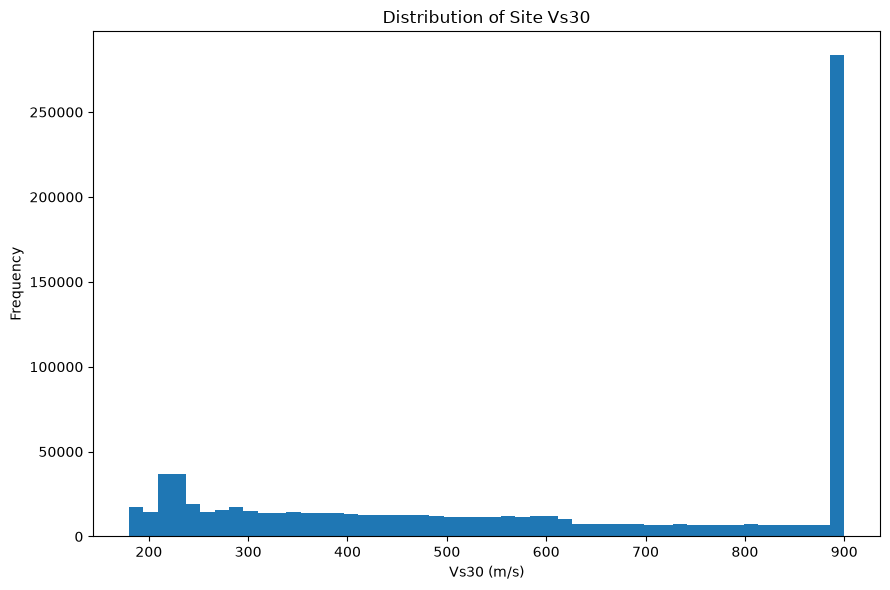

In [25]:
plt.figure(figsize=(9, 6))

plt.hist(
    dataset["Vs30_clean"].dropna(),
    bins=50
)

plt.xlabel(
    "Vs30 (m/s)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Site Vs30"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "vs30_distribution.png",
    dpi=200
)

plt.show()

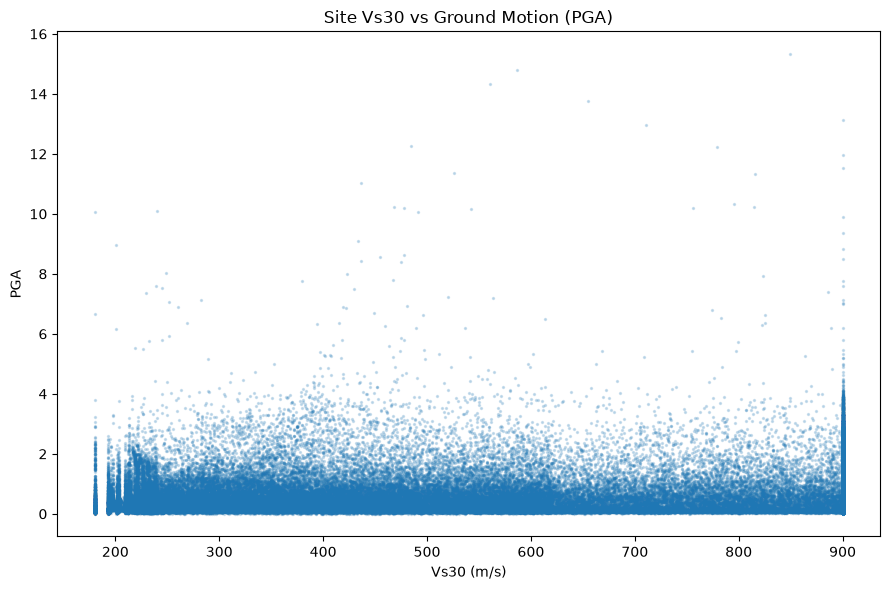

In [26]:
vs30_plot = dataset[
    [
        "Vs30_clean",
        "PGA"
    ]
].dropna()

vs30_plot = vs30_plot[
    vs30_plot["PGA"] > 0
].sample(
    n=min(
        100000,
        len(vs30_plot)
    ),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    vs30_plot["Vs30_clean"],
    vs30_plot["PGA"],
    s=2,
    alpha=0.2
)

plt.xlabel(
    "Vs30 (m/s)"
)

plt.ylabel(
    "PGA"
)

plt.title(
    "Site Vs30 vs Ground Motion (PGA)"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "vs30_vs_pga.png",
    dpi=200
)

plt.show()

In [27]:
def classify_vs30(v):

    if pd.isna(v):
        return "Unknown"

    if v < 180:
        return "Very Soft"

    elif v < 360:
        return "Soft Soil"

    elif v < 760:
        return "Stiff Soil / Rock"

    else:
        return "Rock"


dataset["site_class"] = (
    dataset["Vs30_clean"]
    .apply(classify_vs30)
)

print(
    dataset["site_class"]
    .value_counts()
)

site_class
Unknown              2039864
Rock                  343594
Stiff Soil / Rock     293413
Soft Soil             235868
Name: count, dtype: int64


In [28]:
site_summary = (
    dataset
    .groupby("site_class", observed=True)
    .agg(
        observations=("PGA", "size"),
        median_pga=("PGA", "median"),
        mean_pga=("PGA", "mean"),
        max_pga=("PGA", "max")
    )
    .reset_index()
)

display(site_summary)

,site_class,observations,median_pga,mean_pga,max_pga
0,Rock,343594,0.58,0.804661,15.32
1,Soft Soil,235868,0.35,0.534774,10.52
2,Stiff Soil / Rock,293413,0.40,0.633063,16.56
3,Unknown,2039864,0.22,0.563671,90.17


In [29]:
geology_dataset_file = (
    INTERIM_DIR /
    "earthquake_ground_motion_vs30.csv"
)

dataset.to_csv(
    geology_dataset_file,
    index=False
)

print(
    "Saved:",
    geology_dataset_file
)

print(
    "Rows:",
    f"{len(dataset):,}"
)

print(
    "Columns:",
    len(dataset.columns)
)

Saved: C:\Documents\Earthquake_ML_DL\data\interim\earthquake_ground_motion_vs30.csv
Rows: 2,912,739
Columns: 18
